INFORMACIÓN DE LA RED
Número de nodos: 8
Número de conexiones: 16

LISTA DE NODOS:
Nodos: [1, 2, 3, 4, 5, 6, 7, 8]

LISTA DE CONEXIONES (direccionadas):
  1 → 2
  1 → 8
  2 → 3
  2 → 1
  3 → 4
  3 → 2
  4 → 5
  4 → 3
  5 → 6
  5 → 4
  6 → 7
  6 → 5
  7 → 8
  7 → 6
  8 → 1
  8 → 7

VERIFICACIÓN DE CONEXIONES POR NODO
Nodo 1:
  → Envía a: [2, 8] (Total: 2)
  ← Recibe de: [2, 8] (Total: 2)

Nodo 2:
  → Envía a: [3, 1] (Total: 2)
  ← Recibe de: [1, 3] (Total: 2)

Nodo 3:
  → Envía a: [4, 2] (Total: 2)
  ← Recibe de: [2, 4] (Total: 2)

Nodo 4:
  → Envía a: [5, 3] (Total: 2)
  ← Recibe de: [3, 5] (Total: 2)

Nodo 5:
  → Envía a: [6, 4] (Total: 2)
  ← Recibe de: [4, 6] (Total: 2)

Nodo 6:
  → Envía a: [7, 5] (Total: 2)
  ← Recibe de: [5, 7] (Total: 2)

Nodo 7:
  → Envía a: [8, 6] (Total: 2)
  ← Recibe de: [6, 8] (Total: 2)

Nodo 8:
  → Envía a: [1, 7] (Total: 2)
  ← Recibe de: [1, 7] (Total: 2)



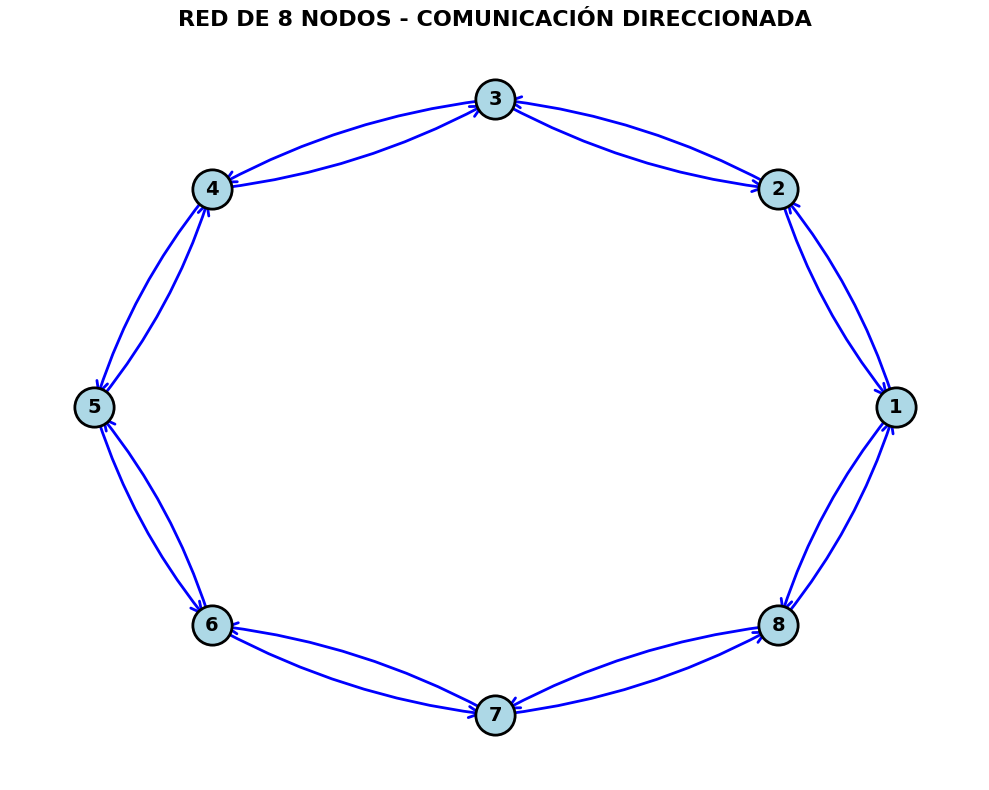

MATRIZ DE ADYACENCIA
(Fila → Columna: 1 si hay conexión, 0 si no)

   1  2  3  4  5  6  7  8
  -------------------------
1 | 0  1  0  0  0  0  0  1
2 | 1  0  1  0  0  0  0  0
3 | 0  1  0  1  0  0  0  0
4 | 0  0  1  0  1  0  0  0
5 | 0  0  0  1  0  1  0  0
6 | 0  0  0  0  1  0  1  0
7 | 0  0  0  0  0  1  0  1
8 | 1  0  0  0  0  0  1  0

ANÁLISIS DE LA RED:
- Cada nodo tiene EXACTAMENTE 2 conexiones de salida
- Cada nodo tiene EXACTAMENTE 2 conexiones de entrada
- La red forma un anillo direccionado
- La comunicación es bidireccional entre nodos consecutivos


In [3]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.DiGraph()

nodos = [1, 2, 3, 4, 5, 6, 7, 8]
G.add_nodes_from(nodos)

conexiones = [
    (1, 2), (1, 8),
    (2, 3), (2, 1),
    (3, 4), (3, 2),
    (4, 5), (4, 3),
    (5, 6), (5, 4),
    (6, 7), (6, 5),
    (7, 8), (7, 6),
    (8, 1), (8, 7)
]

G.add_edges_from(conexiones)

print("=" * 50)
print("INFORMACIÓN DE LA RED")
print("=" * 50)
print(f"Número de nodos: {G.number_of_nodes()}")
print(f"Número de conexiones: {G.number_of_edges()}")
print("\nLISTA DE NODOS:")
print(f"Nodos: {list(G.nodes())}")
print("\nLISTA DE CONEXIONES (direccionadas):")
for edge in G.edges():
    print(f"  {edge[0]} → {edge[1]}")

print("\n" + "=" * 50)
print("VERIFICACIÓN DE CONEXIONES POR NODO")
print("=" * 50)
for nodo in nodos:
    salida = list(G.successors(nodo))
    entrada = list(G.predecessors(nodo))
    print(f"Nodo {nodo}:")
    print(f"  → Envía a: {salida} (Total: {len(salida)})")
    print(f"  ← Recibe de: {entrada} (Total: {len(entrada)})")
    print()

plt.figure(figsize=(10, 8))

pos = nx.circular_layout(G)

nx.draw_networkx_nodes(G, pos, node_size=800, node_color='lightblue',
                       edgecolors='black', linewidths=2)

nx.draw_networkx_labels(G, pos, font_size=14, font_weight='bold')

nx.draw_networkx_edges(G, pos, edge_color='blue', arrows=True,
                       arrowsize=20, arrowstyle='->', width=2,
                       connectionstyle='arc3,rad=0.1')

plt.title("RED DE 8 NODOS - COMUNICACIÓN DIRECCIONADA",
          fontsize=16, fontweight='bold')
plt.axis('off')
plt.tight_layout()

plt.show()

print("=" * 50)
print("MATRIZ DE ADYACENCIA")
print("=" * 50)
print("(Fila → Columna: 1 si hay conexión, 0 si no)")
print()

matriz = nx.adjacency_matrix(G).todense()

print("   " + "  ".join([str(n) for n in nodos]))
print("  " + "-" * 25)
for i, fila in enumerate(matriz):
    print(f"{nodos[i]} | " + "  ".join([str(int(x)) for x in fila]))

print("\n" + "=" * 50)
print("ANÁLISIS DE LA RED:")
print("- Cada nodo tiene EXACTAMENTE 2 conexiones de salida")
print("- Cada nodo tiene EXACTAMENTE 2 conexiones de entrada")
print("- La red forma un anillo direccionado")
print("- La comunicación es bidireccional entre nodos consecutivos")
print("=" * 50)